In [74]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import rioxarray
import xcdat as xc
import seaborn as sns
import unityandnormal as u_n
import os
from datetime import timedelta
import warnings  
warnings.filterwarnings("ignore")
from pyextremes import EVA
from pyextremes import plot_threshold_stability
from pyextremes import plotting
from pyextremes import models

import DataAndCorr as DC

In [75]:
def spearmanr_pval(x,y):
    return stats.spearmanr(x,y).pvalue


def matrixplot(data, figname):
    merged_data_i = pd.DataFrame(data.reset_index())
    merged_data_i = merged_data_i.drop(columns=["time"])

    temp_expl_corr = np.array(merged_data_i.corr(method='spearman'))

    temp_expl_pval = np.array(merged_data_i.corr(method=spearmanr_pval))

    u_n.corrmatrixplot(merged_data_i.columns, temp_expl_corr, temp_expl_pval)
    plt.savefig(figname, dpi=300)

In [76]:
# P_grid = xr.open_dataset("Data/Duoro_up_P.nc")
# P = P_grid.spatial.average('rr', axis=["X", "Y"])
# P = P.bounds.add_missing_bounds()

# T_grid = xr.open_dataset("Data/Duoro_up_T.nc")
# T = T_grid.spatial.average('tg', axis=["X", "Y"])
# T = T.bounds.add_missing_bounds()

In [77]:
def Qtomonth(loc, col_name):

    Q = xr.open_dataset(loc)
    Q = Q.assign_coords(Date=Q["Date"]).swap_dims({"index": "Date"})
    Q = Q.drop_vars("index")
    Q = Q.rename({"Date": "time"})
    Q = Q.rename({"Q":col_name})
    return Q

def prepareQs(folderloc):
    p = folderloc
    listofdischarges  = []

    for i,e in enumerate(os.scandir(p)):
        if e.is_file():
            with open(e.path, "r") as f:
                print("Reading:", e.name)
                Q = Qtomonth(e.path, str(i))
                Q = Q[[str(i)]].to_dataframe()#.reset_index()[["time", str(i)]]
                listofdischarges.append(Q)

    
    Qs = pd.concat(listofdischarges, axis=1, join="inner")
    # Qs.dropna(inplace=True)

    return Qs

def combineQ_P_T(P,T):
    qs = prepareQs("Data\Discharges")

    P_df = P[["rr"]].to_dataframe()
    T_df = T[["tg"]].to_dataframe()

    catchment = pd.concat([P_df,T_df,qs],axis=1,join="inner")

# pisuerga = pisuerga.set_index("time")
    catchment = catchment.rename(columns={'rr':'P', 'tg':'T'})
    f, axs = plt.subplots(3,1,sharex=True, figsize=(12,8))
    axs[0].plot(catchment['P'])
    axs[1].plot(catchment['T'])
    axs[2].plot(catchment[['0','1','2']])
    return catchment


Reading: Q_Duero_0.nc
Reading: Q_Duero_1.nc
Reading: Q_Duero_2.nc
Reading: Q_Duero_3.nc


<Axes: xlabel='time'>

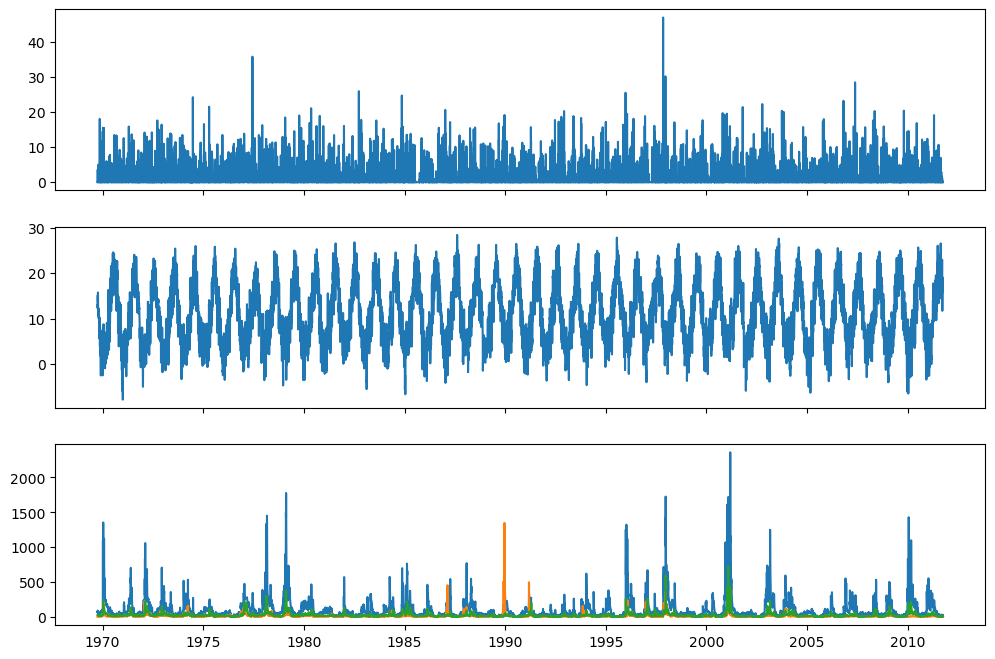

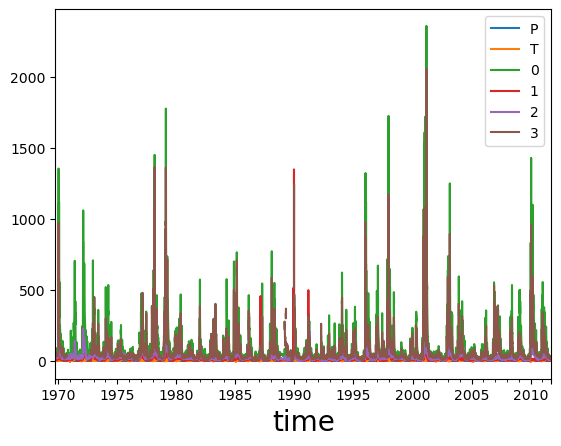

In [117]:
PT = pd.read_pickle("Data/DueroData.pkl")
P = PT["P"]
T = PT["T"]

Q_Duero = DC.combineQ_P_T(P,T,"Data/Discharges/Duero")
Q_Duero.plot()

In [79]:
Q_Duero.to_pickle("Data/DueroData.pkl")

In [118]:
# df = pd.read_pickle("DueroData.pkl")
# df.plot()
df = Q_Duero

In [99]:
# yearlysum = df['P'].resample("YE").sum()
# print(np.mean(yearlysum))

In [100]:
# def lagcheck(df, columnname, lagname, thresholdvalue, declustime):

#     df_origin = df.copy()

#     lag = 15
#     df = df.iloc[lag:-lag]

#     # print(df_trimmed, df)

#     indices = df[columnname].resample('ME').indices
#     df_thresh = df[columnname].resample('ME').max()

#     argmax = []

#     for maxval, ind in zip(df_thresh, indices.values()):
#         what = df[columnname].iloc[ind]==maxval
#         argmax.append(what[what.values==True].index)

#     maxtimes = pd.DataFrame(argmax[:])
#     maxtimes = maxtimes[0]

#     df_thresh = pd.DataFrame(df_thresh.values, index=maxtimes)
#     df_thresh.dropna(inplace=True)

#     df_thresh = df_thresh.loc[df_thresh.values>thresholdvalue]

    
#     df_thresh.index.name = "time"

#     Q_1_lags = pd.DataFrame(df_origin[lagname].loc[df_thresh.index])
#     Q_1_lags.rename(columns={lagname:'lag 0'}, inplace=True)
#     Q_1_lags.reset_index(drop=True, inplace=True)

#     for i in range(lag-1):
#         laggedseries = pd.DataFrame(df_origin[lagname].loc[df_thresh.index-timedelta(days=i+1)])
#         laggedseries.rename(columns={lagname:f'lag {i+1}'}, inplace=True)
#         laggedseries.reset_index(drop=True, inplace=True)

#         # print(laggedseries)
#         Q_1_lags = pd.concat([Q_1_lags, laggedseries], axis=1)

#     return Q_1_lags, df_thresh

In [101]:
# def lagcheck(df, columnname, lagname, thresholdvalue, declustime):

#     df_origin = df.copy()

#     lag = 14
#     df = df.iloc[lag:-lag]

#     argmax = []


#     model = EVA(df['0'])
#     model.get_extremes(method="POT", threshold=thresholdvalue, r=declustime)

#     df_thresh = model.extremes
    
#     df_thresh.index.name = "time"

#     Q_1_lags = pd.DataFrame(df_origin[lagname].loc[df_thresh.index])
#     Q_1_lags.rename(columns={lagname:f'{lagname} lag 0'}, inplace=True)
#     Q_1_lags.reset_index(drop=True, inplace=True)

#     for i in range(lag-1):
#         laggedseries = pd.DataFrame(df_origin[lagname].loc[df_thresh.index-timedelta(days=i+1)])
#         laggedseries.rename(columns={lagname:f'{lagname}:lag {i+1}'}, inplace=True)
#         laggedseries.reset_index(drop=True, inplace=True)

#         # print(laggedseries)
#         Q_1_lags = pd.concat([Q_1_lags, laggedseries], axis=1)

#     return Q_1_lags, df_thresh

### Autocorrelation of discharge on days prior to max discharge event

Use autocorrelation to check for i.i.d assumption

(80, 40)
(80, 40)
(80, 40)
(80, 40)
(80, 40)
(73, 40)


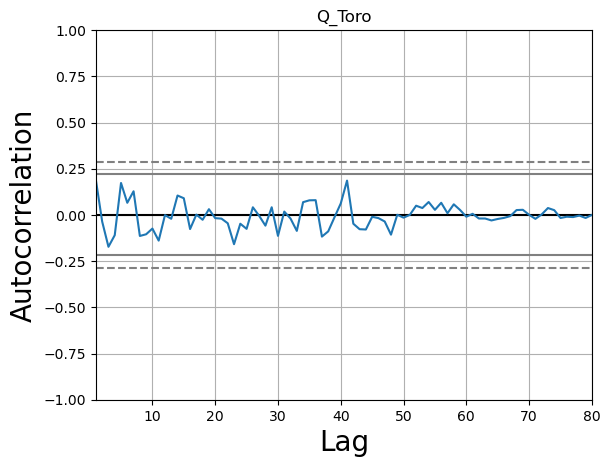

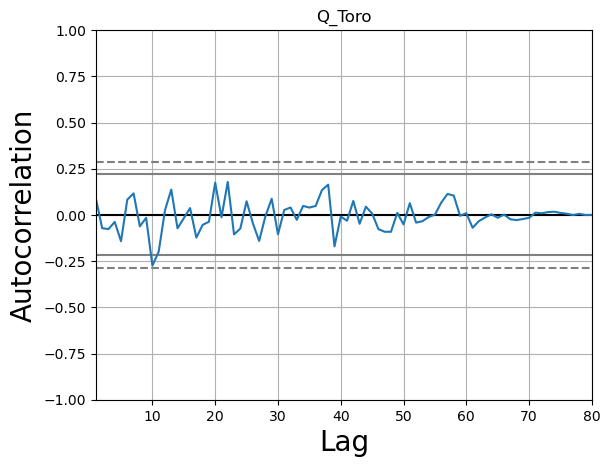

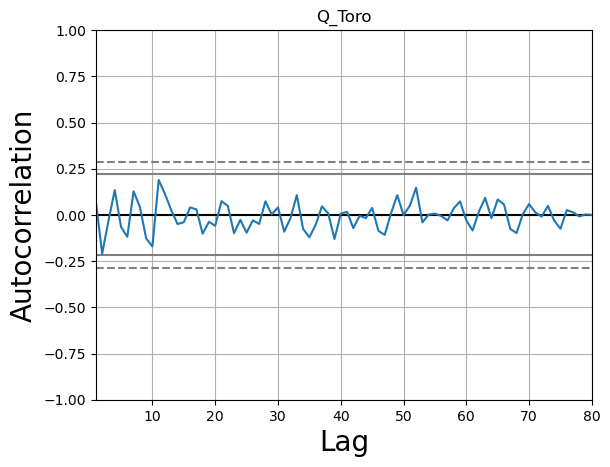

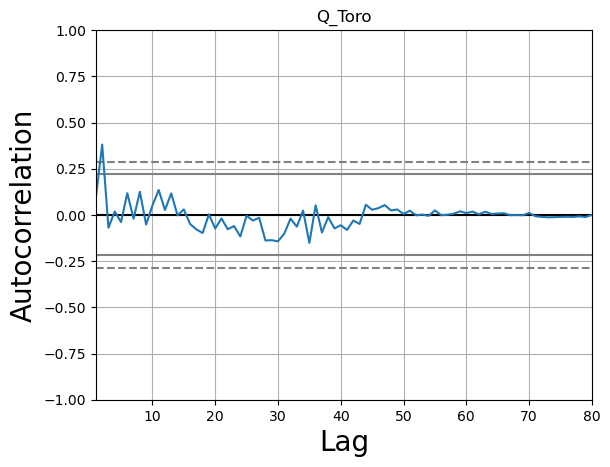

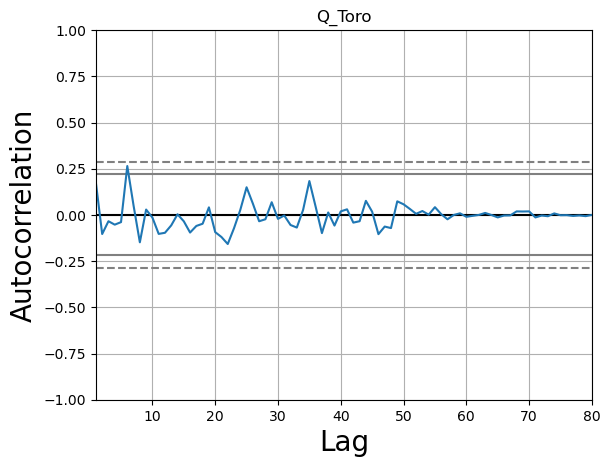

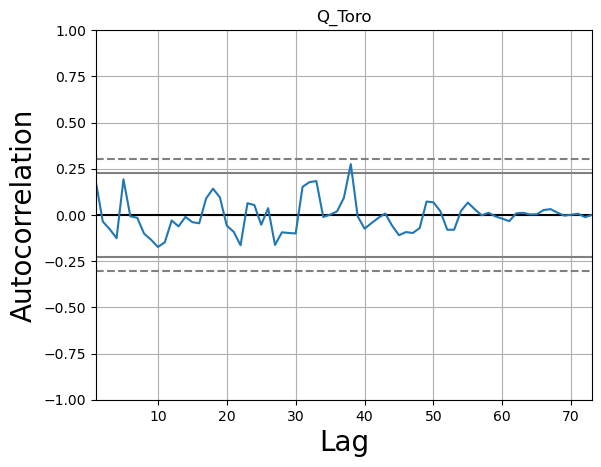

In [119]:
Qs = []
maxes = []
for lagname in ['0','P', 'T', '1', '2', '3']:
    lags, maxvals= DC.lagcheck(df, '0', lagname, 360, "48h",40)
    lags.dropna(inplace=True)
    Qs.append(lags)
    maxes.append(maxvals)
    print(lags.shape)
    plt.figure()
    pd.plotting.autocorrelation_plot(lags.iloc[:,0])
    plt.title("Q_Toro")

rain = Qs[1]
rainacc = rain.cumsum(axis=1)
# print(rainacc)
Qs[1] = rainacc


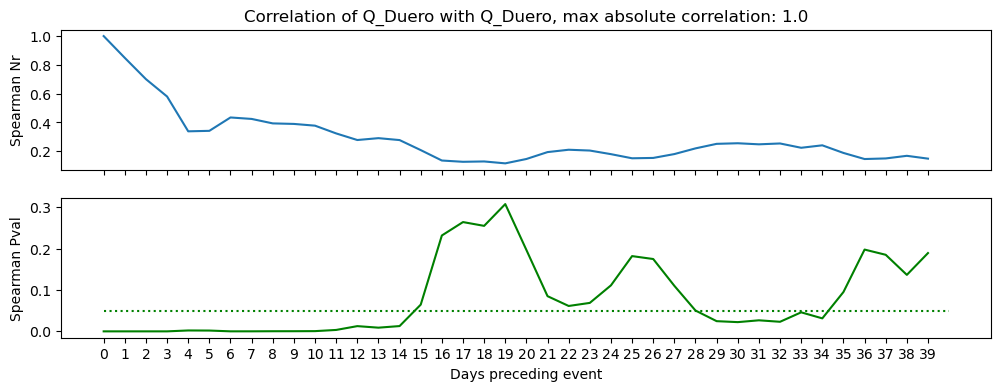

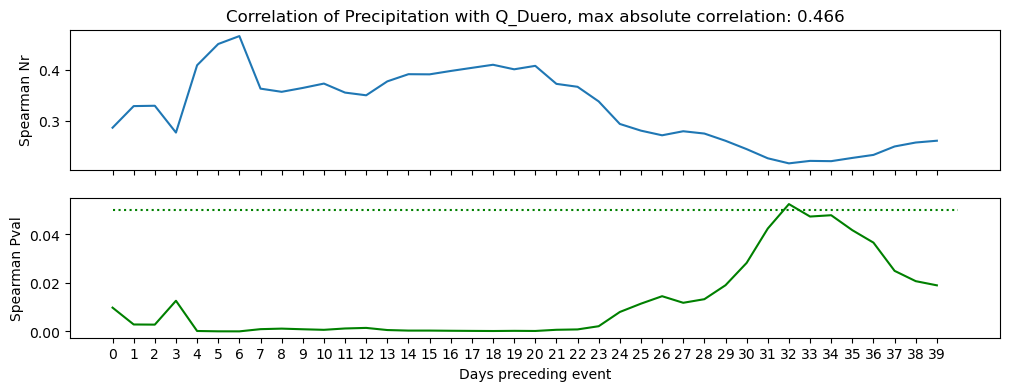

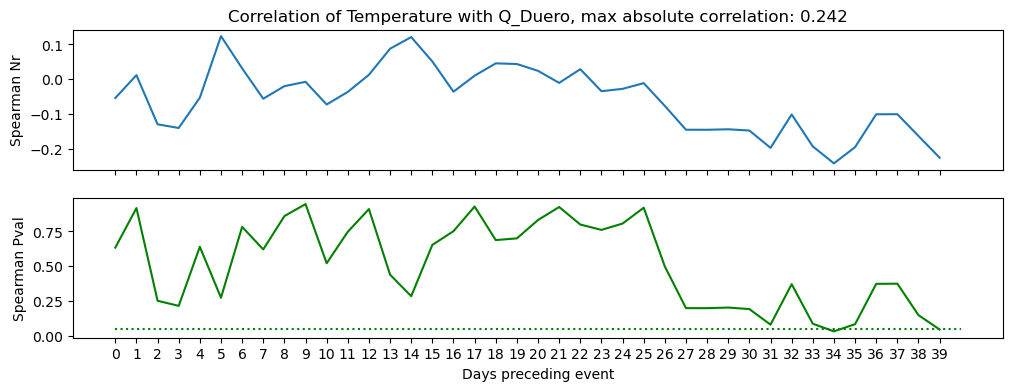

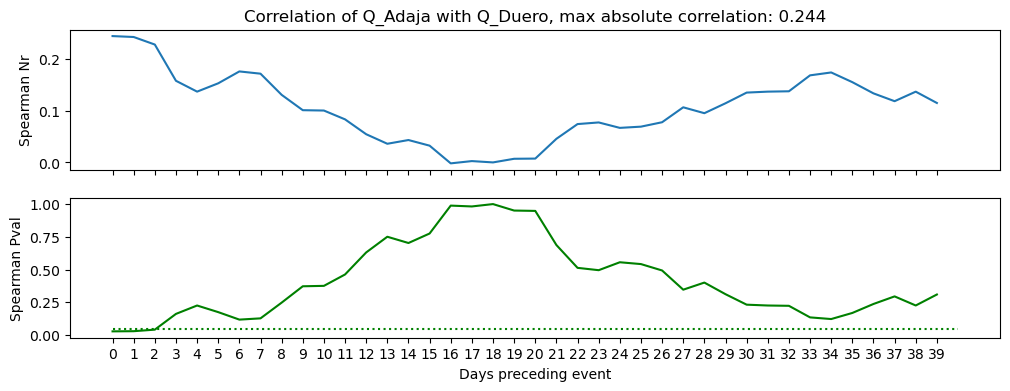

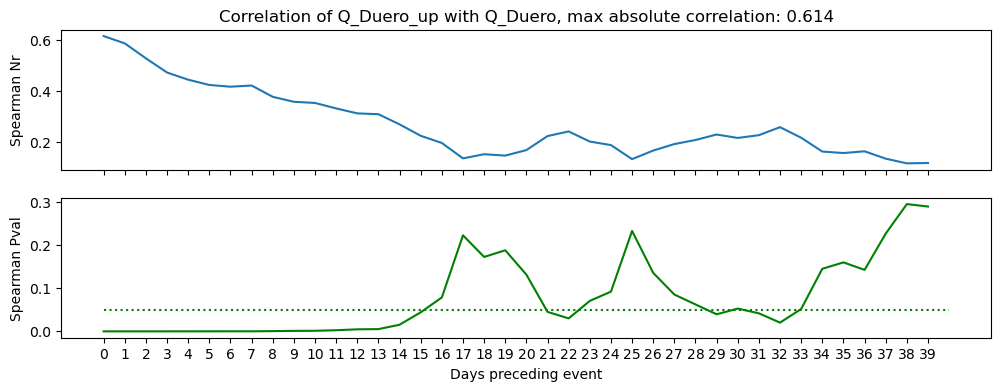

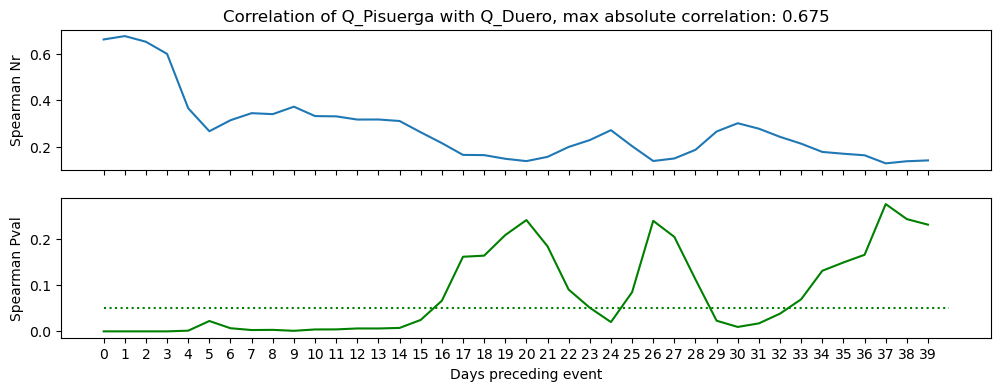

In [133]:


for Q,name in zip(Qs[:], ['Q_Duero','Precipitation', 'Temperature', 'Q_Adaja', 'Q_Duero_up', 'Q_Pisuerga']):
    Q["Ref"] = Qs[0].iloc[:,0]
    col = Q.pop("Ref")
    Q.insert(0, col.name, col)

    corrmat = Q.corr(method='spearman')
    corrmat = corrmat.iloc[1:,0]
    pvals = Q.corr(method=spearmanr_pval)
    pvals = pvals.iloc[1:,0]
    f, axs = plt.subplots(2,1, sharex=True)

    axs[0].set_title(f"Correlation of {name} with Q_Duero, max absolute correlation: {np.round(max(abs(corrmat)),3)}")
    axs[0].plot(corrmat)
    axs[0].set_ylabel("Spearman Nr", fontsize="10")
    axs[0].figure.set_size_inches(12, 4)
    # axs[0].set_ylim((0.2,1))
    axs[1].plot(pvals, color='green')
    axs[1].hlines(0.05, 0,40, linestyle = 'dotted', color='green')
    axs[1].set_ylabel("Spearman Pval", fontsize="10")
    axs[1].set_xlabel("Days preceding event", fontsize="10")
    f.savefig(f"DLagCorr_{name}.png")



# print(Qs)

In [121]:
dfselected = pd.DataFrame(df.loc[maxes[0].index])
print(dfselected.columns)

Index(['P', 'T', '0', '1', '2', '3'], dtype='str')


In [122]:
dfselected["Q_Down_4D"] = df['0'].loc[maxes[0].index-timedelta(days=5)].values


In [123]:
rainlag = rainacc.iloc[:,7] 
#pd.DataFrame(df['P'].loc[maxes[0].index-timedelta(days=8)].values, columns=['0'])
# print(templag)
# for i in range(1,7):
#     rainlag[str(i)] = df['P'].loc[maxes[0].index-timedelta(days=i)].values
    # dfselected['P'] = rainlag[str(i)].values
    # print(i, dfselected[['0','P']].corr(method='spearman').P, dfselected[['0','P']].corr(method=spearmanr_pval).P)

dfselected['P'] = rainlag.values
# print(rainlag, dfselected['P'])

In [124]:
templag = pd.DataFrame(df['T'].loc[maxes[0].index-timedelta(days=0)].values, columns=['7'])
# print(templag)
for i in range(1,30):
    templag[str(i)] = df['T'].loc[maxes[0].index-timedelta(days=i)].values
    dfselected['T'] = templag[str(i)].values
    # print(i, dfselected[['0','T']].corr(method='spearman').T, dfselected[['0','T']].corr(method=spearmanr_pval).T)

# # print(templag)

dfselected['T'] = templag.mean(axis=1).values


In [125]:
print(dfselected)

                    P          T        0       1      2      3  Q_Down_4D
time                                                                      
1970-01-13  59.232151   3.619960  1355.00  190.86  211.4  722.5     1102.0
1970-02-09   3.902843   4.669211   554.00   28.13   63.4  137.5      338.0
1971-05-28  38.877940  10.432484   705.00   97.00  121.8    NaN      502.5
1971-06-16  23.508122  10.622657   420.30   47.55   78.8    NaN      330.8
1972-02-14  23.769781   2.606160  1059.87   94.98  173.1    NaN      837.5
...               ...        ...      ...     ...    ...    ...        ...
2010-03-28  17.306689   5.519948   465.00   12.70   72.7  265.0      387.0
2010-12-10  41.372663   3.457229   366.00    4.09   31.3  223.0       65.7
2010-12-25  30.192675   2.742885   461.00    8.87   25.8  256.0      110.0
2011-01-10  36.286091   3.610116   555.00    8.79   48.1  343.0      131.0
2011-02-22  20.092058   3.226381   378.00    8.13   47.1  195.0      128.0

[80 rows x 7 columns]


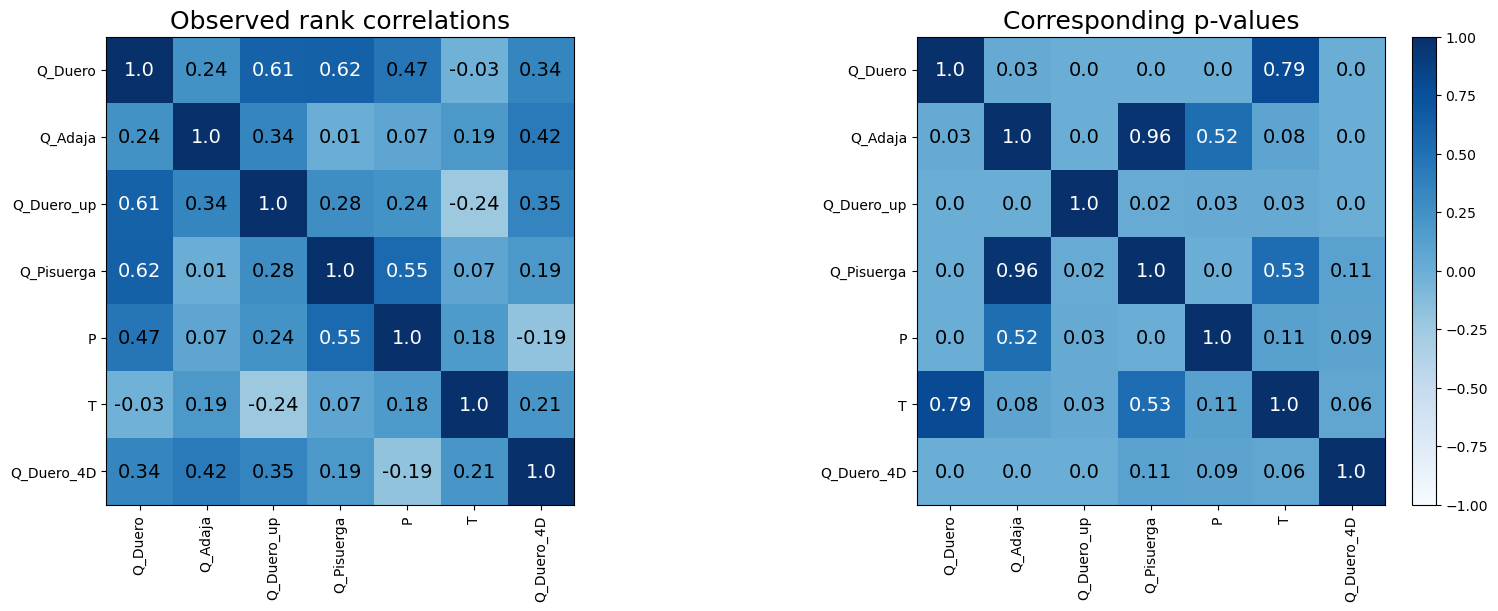

In [126]:
dfselected.columns = ["P", "T", "Q_Duero", "Q_Adaja", "Q_Duero_up", "Q_Pisuerga", "Q_Duero_4D"]
dfselected = dfselected.iloc[:,[2,3,4,5,0,1,6]]

# plt.plot(dfselected)
matrixplot(dfselected, f"Max discharge events at downstream station")
# sns.pairplot(u_n.sd_normal(dfselected), corner=True)

In [127]:

# f, axs = plt.subplots(1,7)
# f.set_figwidth(30)
# f.set_figheight(4)
# for axe, column, method in zip(axs, dfselected.columns, ["POT", "BM", "BM", "BM", "BM", "BM", "BM"]):
#     model = EVA.from_extremes(dfselected[column], method=method)
#     model.fit_model()
#     model.plot_probability("QQ", ax=axe, figsize=(3,3))
#     # model.plot_diagnostic()
#     axe.set_title(column)
#     axe.set
    

In [128]:
import matplotlib as mpl

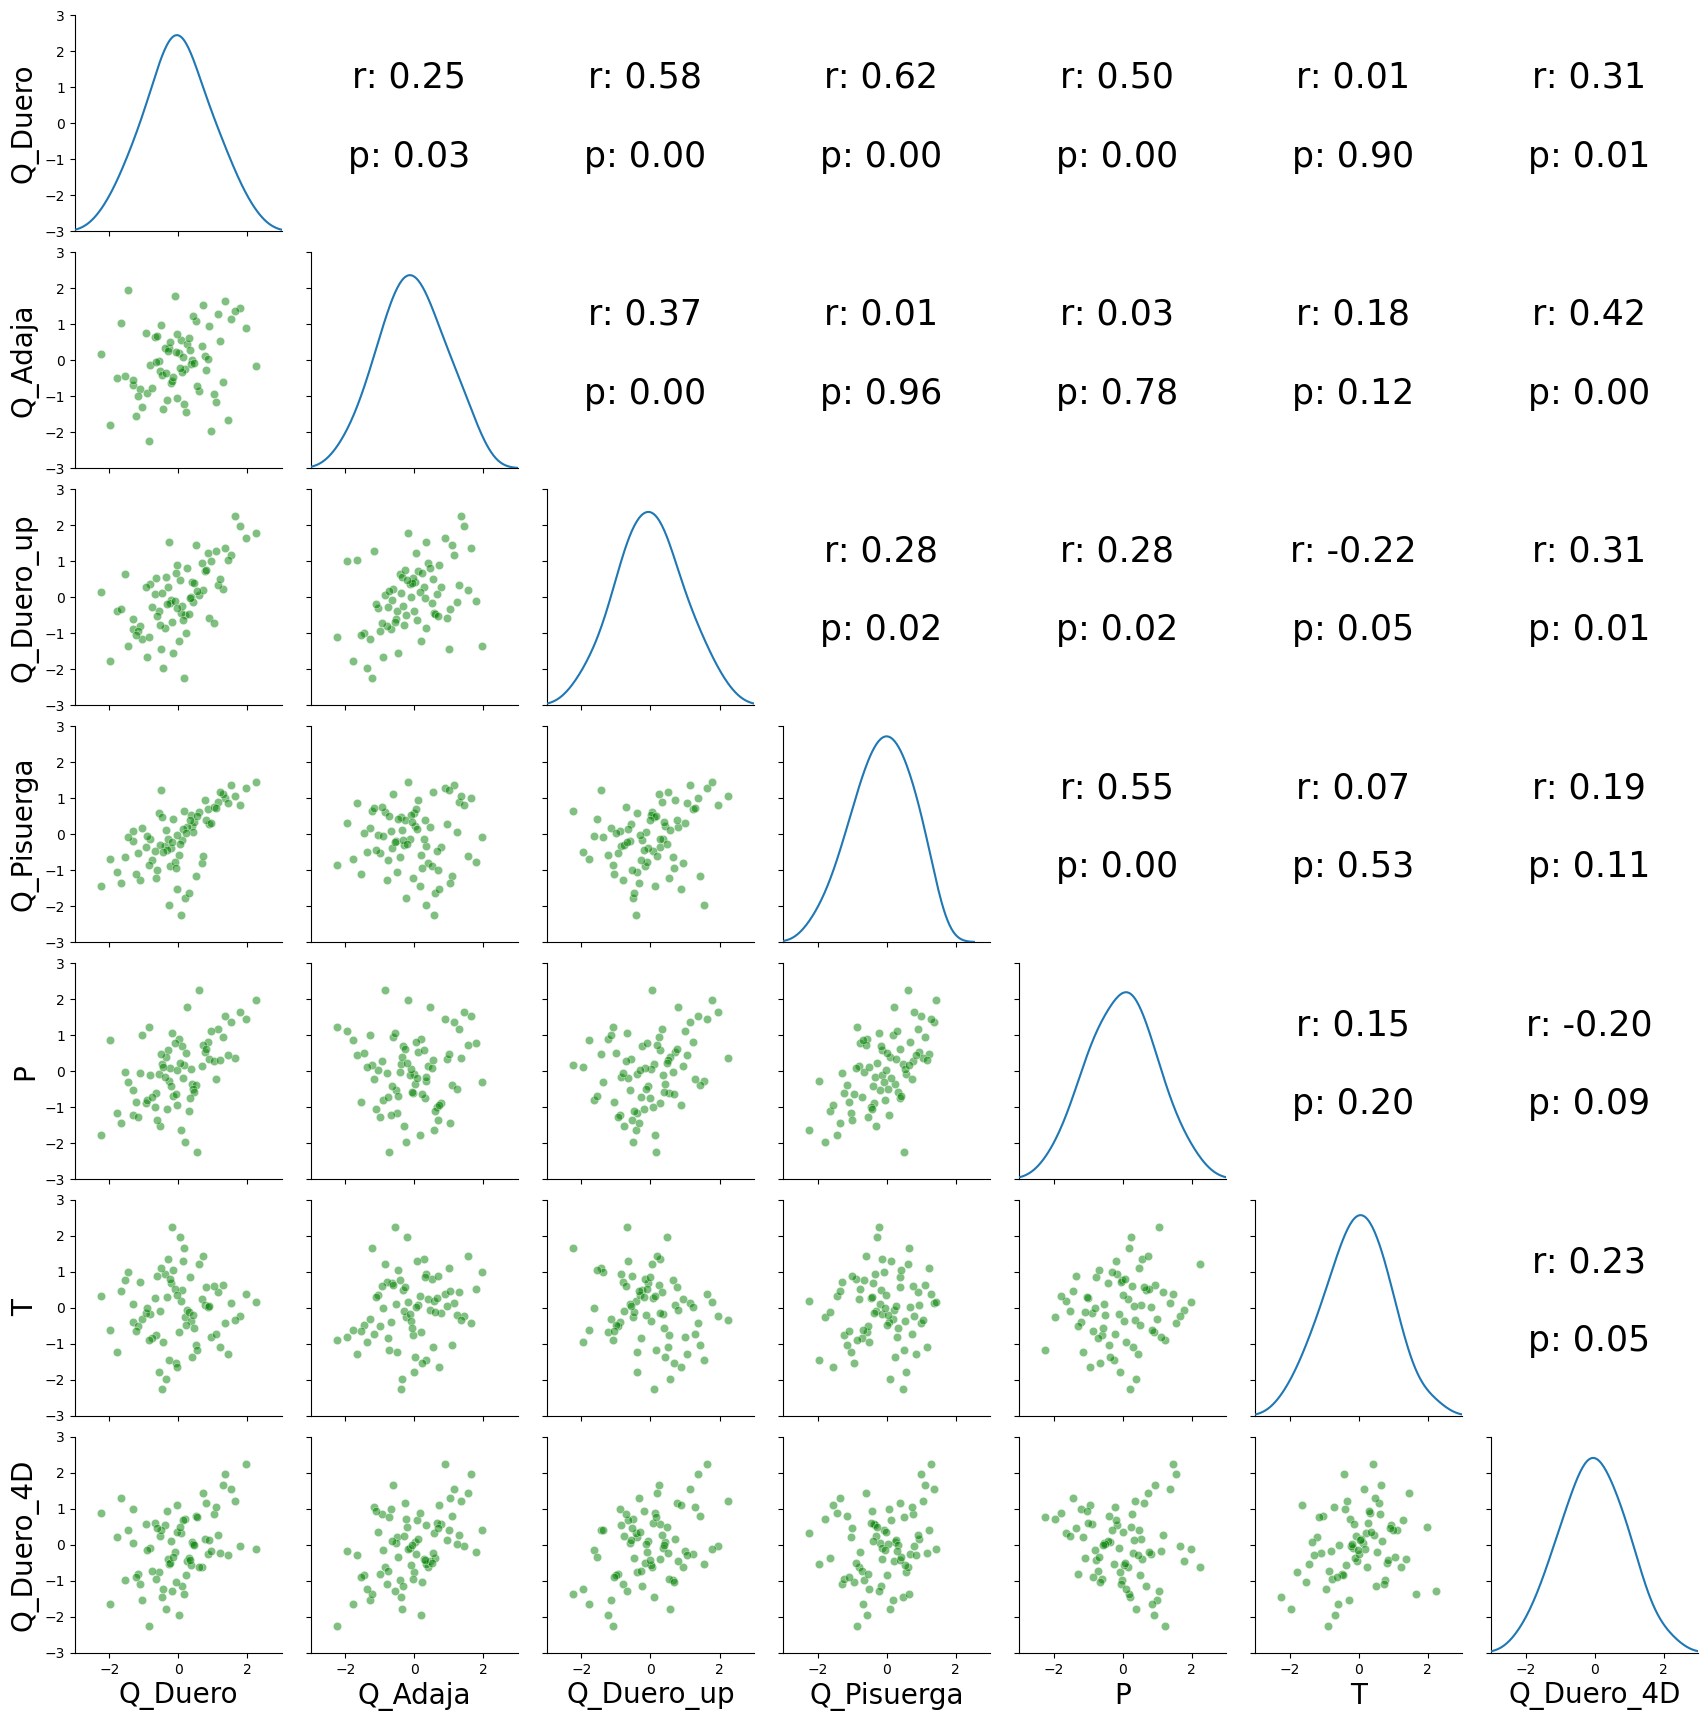

In [129]:
def reg_coef(x,y,label=None,color=None,**kwargs):
    ax = plt.gca()
    r,p = stats.spearmanr(x,y)
    ax.annotate(f'r: {r:.2f} \n\np: {p:.2f} ', xy=(0.5,0.3), xycoords='axes fraction', ha='center', size=25)
    ax.set_axis_off()

iris = u_n.sd_normal(dfselected).dropna()

mpl.rcParams["axes.labelsize"] = 20

g = sns.PairGrid(iris)
g.map_upper(reg_coef)
g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot, alpha=0.5, color='green')
g.set(xlim=(-3,3), ylim=(-3,3))
g.savefig("DueroPairplot.png")



plt.show()

# g = sns.PairGrid(iris)
# g.map_upper(reg_coef)
# g.map_diag(sns.kdeplot)
# g.map_lower(sns.scatterplot, alpha=0.3)
# plt.show()

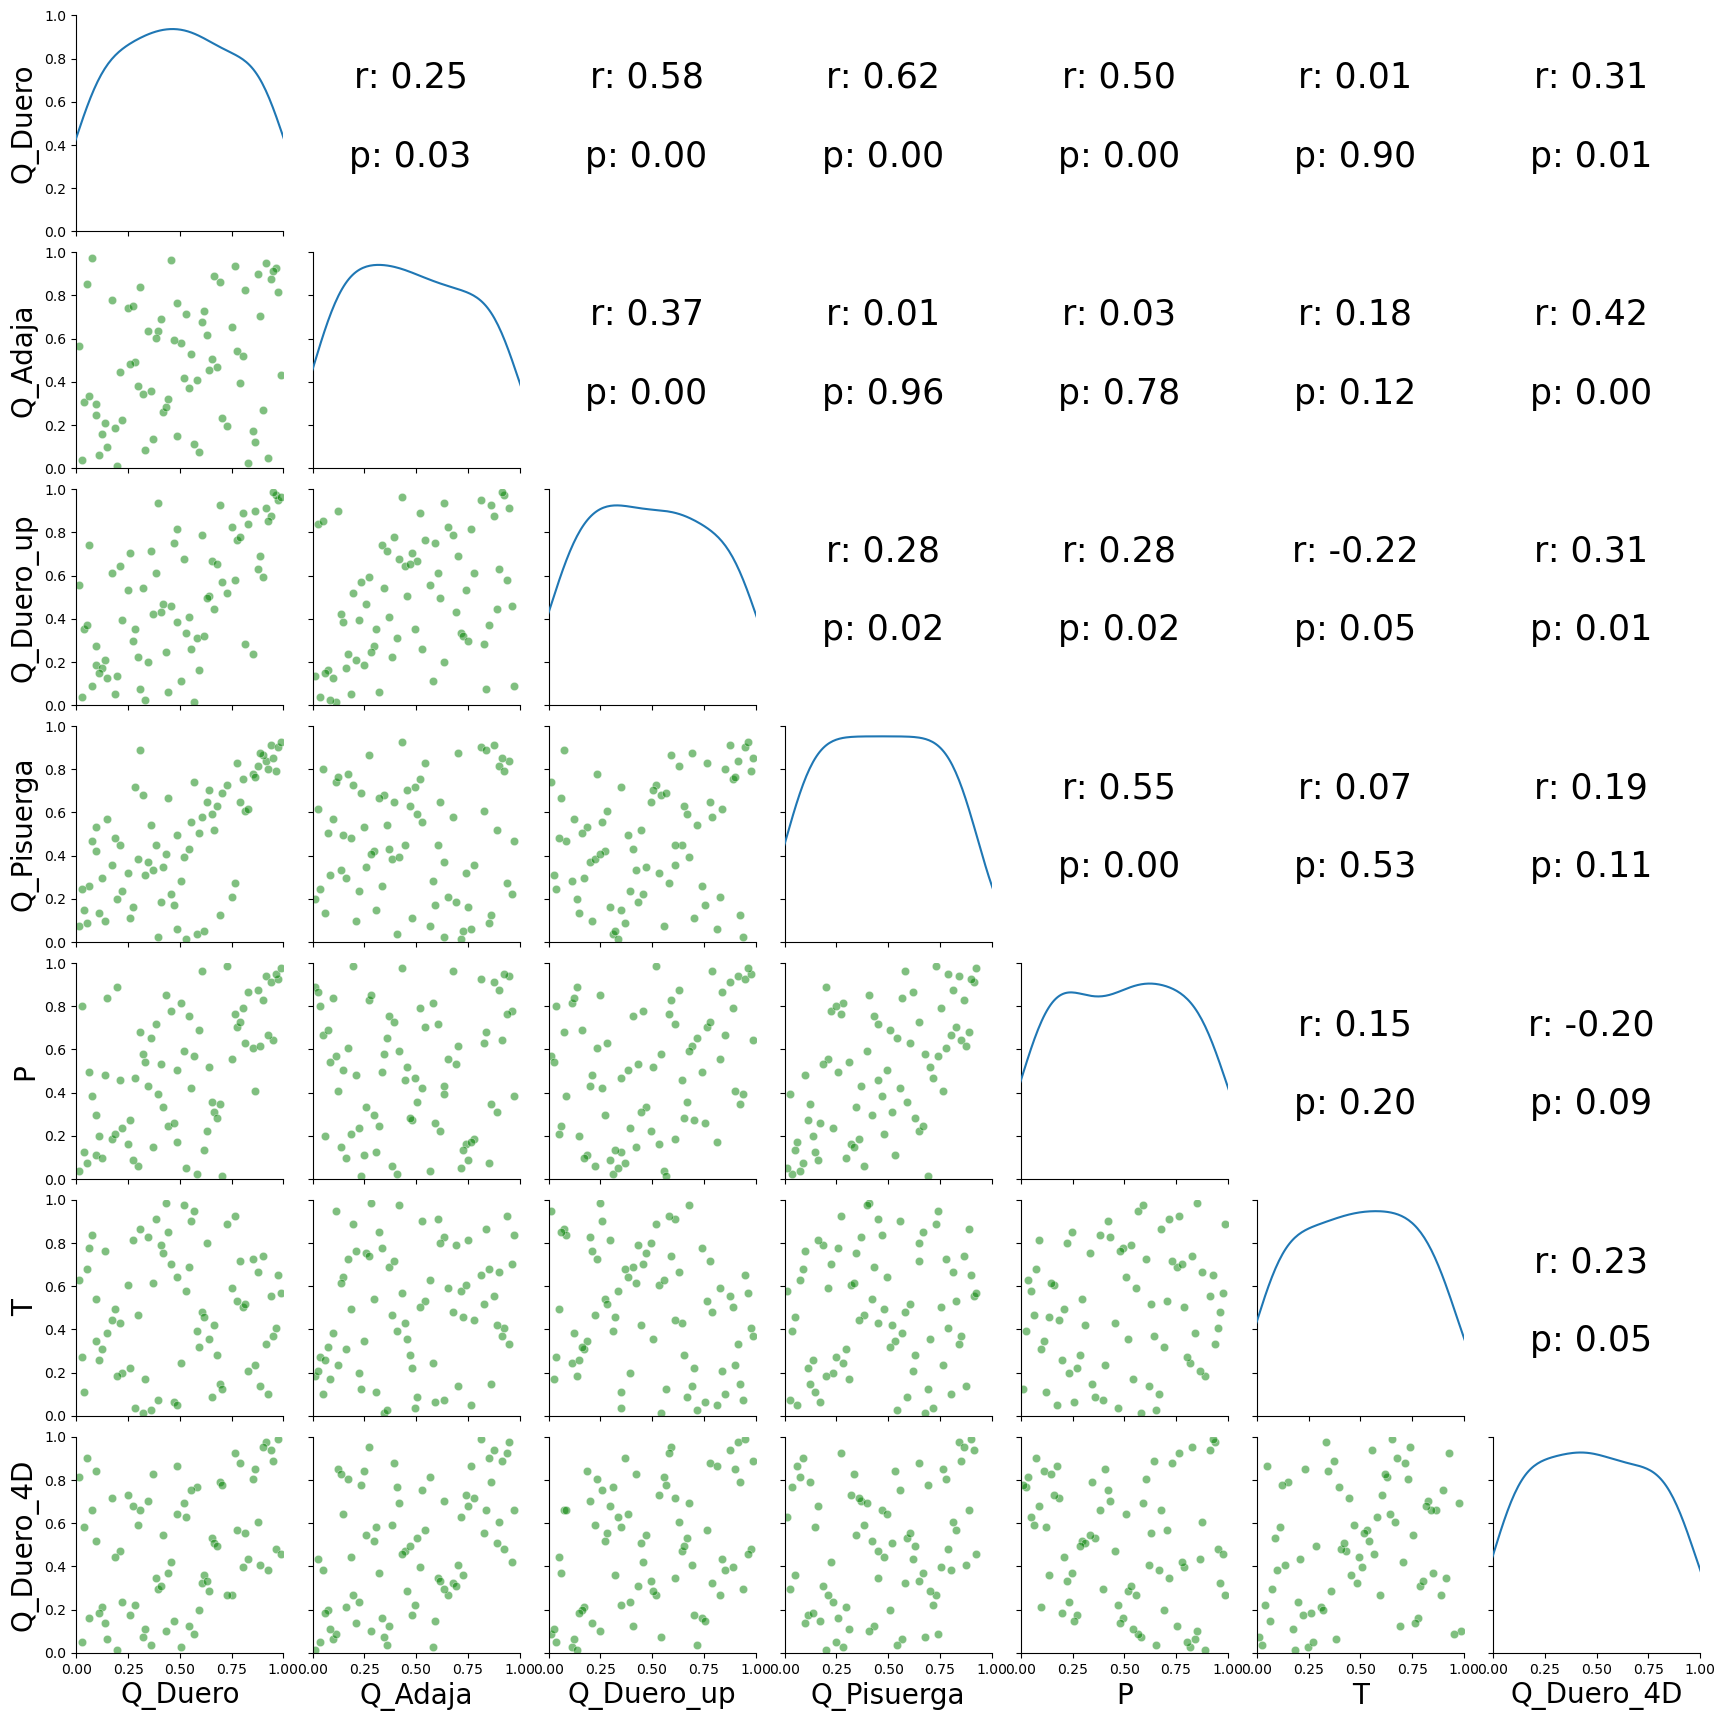

In [130]:
iris = u_n.unity(dfselected).dropna()

mpl.rcParams["axes.labelsize"] = 20

g = sns.PairGrid(iris)
g.map_upper(reg_coef)
g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot, alpha=0.5, color='green')
g.set(xlim=(0,1), ylim=(0,1))
g.savefig("DueroPairplot.png")



plt.show()


In [131]:
# for i in range(3):
#     print(i)
#     dfselected = pd.DataFrame(df.loc[maxes[i].index])
#     # plt.plot(dfselected)
#     matrixplot(dfselected, f"Max discharge events from: {i}")
#     sns.pairplot(u_n.sd_normal(dfselected))


In [132]:


    


# make index from 0 to n-1 because otherwise cvm stat gives error :)



# print(df['1'])
# plt.figure(figsize=(15,5))
# # plt.plot(df.loc[df_thresh.index].shift(-1))

# # plt.plot(df['1'].loc[df_thresh.index-timedelta(days=1)], label="lag 1")
# # plt.plot(df['1'].loc[df_thresh.index-timedelta(days=2)], label ='lag 2')
# # plt.plot(df['1'].loc[df_thresh.index])
# plt.plot(Q_1_lags)
# # plt.plot(df['1'])
# plt.xlim(310,340)
# plt.ylim((100,300))
# plt.legend()
